<a href="https://colab.research.google.com/github/faizaan0619/Portfolio/blob/main/Bivariate_Multivariate_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
titanic = pd.read_csv('train.csv')
flights = pd.read_csv('flights.csv')
iris = pd.read_csv('iris.csv')
tips = pd.read_csv('tips.csv')

In [ ]:
titanic.sample()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0,B22,S


In [ ]:
flights.sample()

,Origin,Destination,Origin City,Origin State,Destination City,Destination State,Passengers,Seats,Flights,Distance,Fly Date,Origin Population,Destination Population
211190,BOS,BGR,Boston,MA,Bangor,ME,482.0,1012.0,23.0,201.0,200604.0,8946954.0,148197.0


In [ ]:
iris.sample()

,Id,Sepal Length (cm),Sepal Width (cm),Petal Length (cm),Petal Width (cm),Species
8,9,4.4,2.9,1.4,0.2,Iris-setosa


In [ ]:
tips.sample()

,total_bill,tip,sex,smoker,day,time,size
135,8.51,1.25,Female,No,Thur,Lunch,2


# 1. Scatter plot (Numerical - Numerical)

<Axes: xlabel='total_bill', ylabel='tip'>

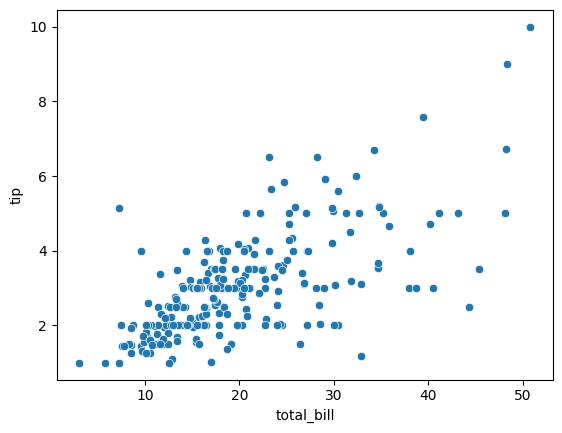

In [ ]:
sns.scatterplot(x=tips['total_bill'], y=tips['tip'])

<Axes: xlabel='total_bill', ylabel='tip'>

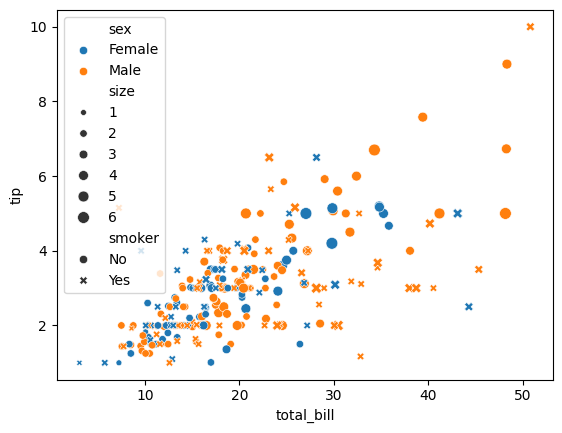

In [ ]:
#sns.scatterplot(x=tips['total_bill'], y=tips['tip'], hue=tips['sex'])
sns.scatterplot(x=tips['total_bill'], y=tips['tip'], hue=tips['sex'],style=tips['smoker'],size=tips['size'])

# 2. Bar Plot (Numerical- Categorical)



<Axes: xlabel='Pclass', ylabel='Fare'>

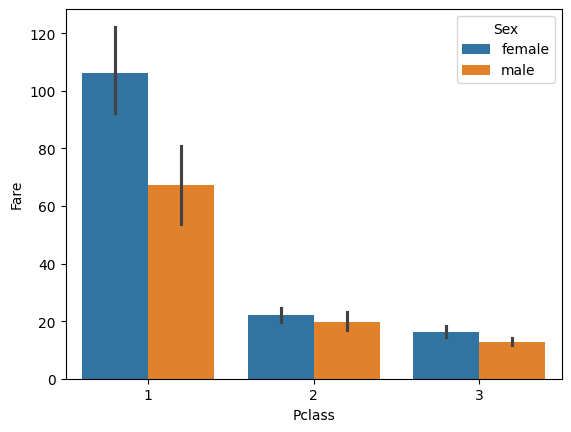

In [ ]:
sns.barplot(x=titanic['Pclass'], y=titanic['Fare'], hue=titanic['Sex'])

<Axes: xlabel='Pclass', ylabel='Fare'>

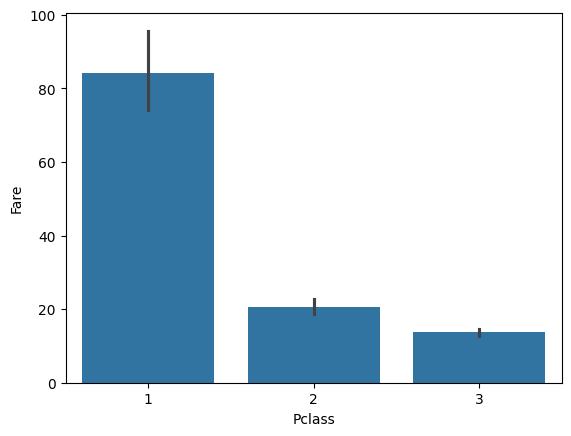

In [ ]:
sns.barplot(x=titanic['Pclass'], y=titanic['Fare'])

# 3. Boxplot (Numerical - Categorical)

<Axes: xlabel='Sex', ylabel='Age'>

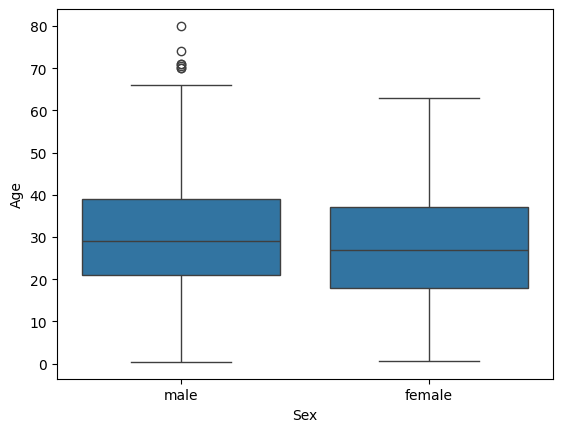

In [ ]:
sns.boxplot(x=titanic['Sex'], y=titanic['Age'])

<Axes: xlabel='Sex', ylabel='Age'>

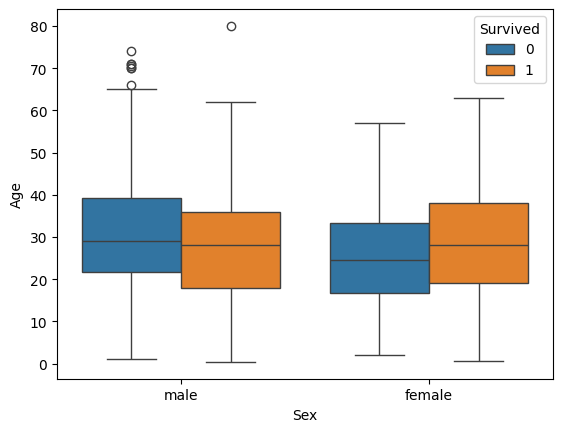

In [ ]:
sns.boxplot(x=titanic['Sex'], y=titanic['Age'], hue=titanic['Survived'])

# 4. Distplot (Numerical - Categorical)

/tmp/ipykernel_3324/972674918.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic['Age'], hist=False)


<Axes: xlabel='Age', ylabel='Density'>

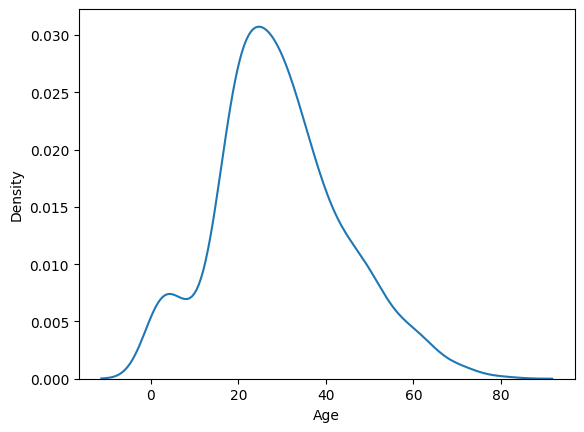

In [ ]:
sns.distplot(titanic['Age'], hist=False)

/tmp/ipykernel_3324/385736575.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic[titanic['Survived']==0]['Age'], hist=False)
/tmp/ipykernel_3324/385736575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic[titanic['Survived']==1]['Age'], hist=False)


<Axes: xlabel='Age', ylabel='Density'>

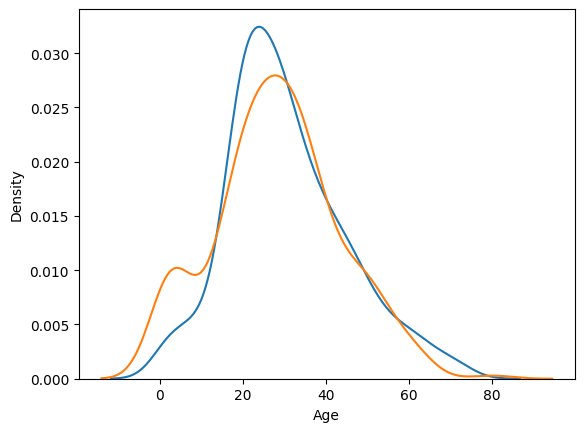

In [ ]:
sns.distplot(titanic[titanic['Survived']==0]['Age'], hist=False)
sns.distplot(titanic[titanic['Survived']==1]['Age'], hist=False)

# 5. HeatMap (Categorical - Categorical)

<Axes: xlabel='Survived', ylabel='Sex'>

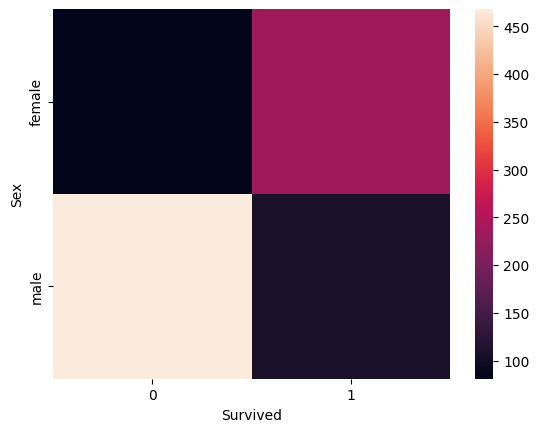

In [ ]:
sns.heatmap(pd.crosstab(titanic['Sex'], titanic['Survived']))

In [ ]:
pd.crosstab(titanic['Sex'], titanic['Survived'], normalize='index') * 100

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


<Axes: xlabel='Sex'>

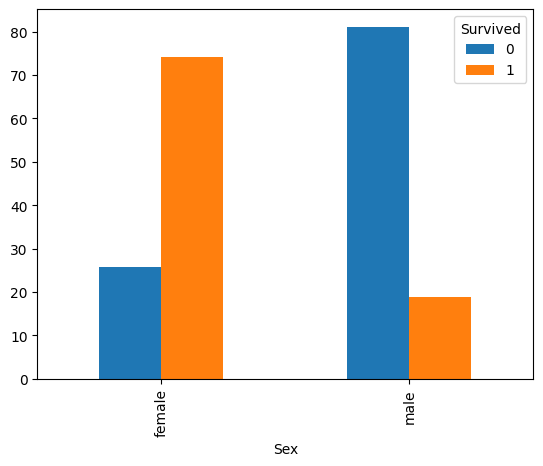

In [ ]:
(pd.crosstab(titanic['Sex'], titanic['Survived'], normalize='index') * 100).plot(kind='bar')

# 6. Clustermap (Categorical - Categorical)

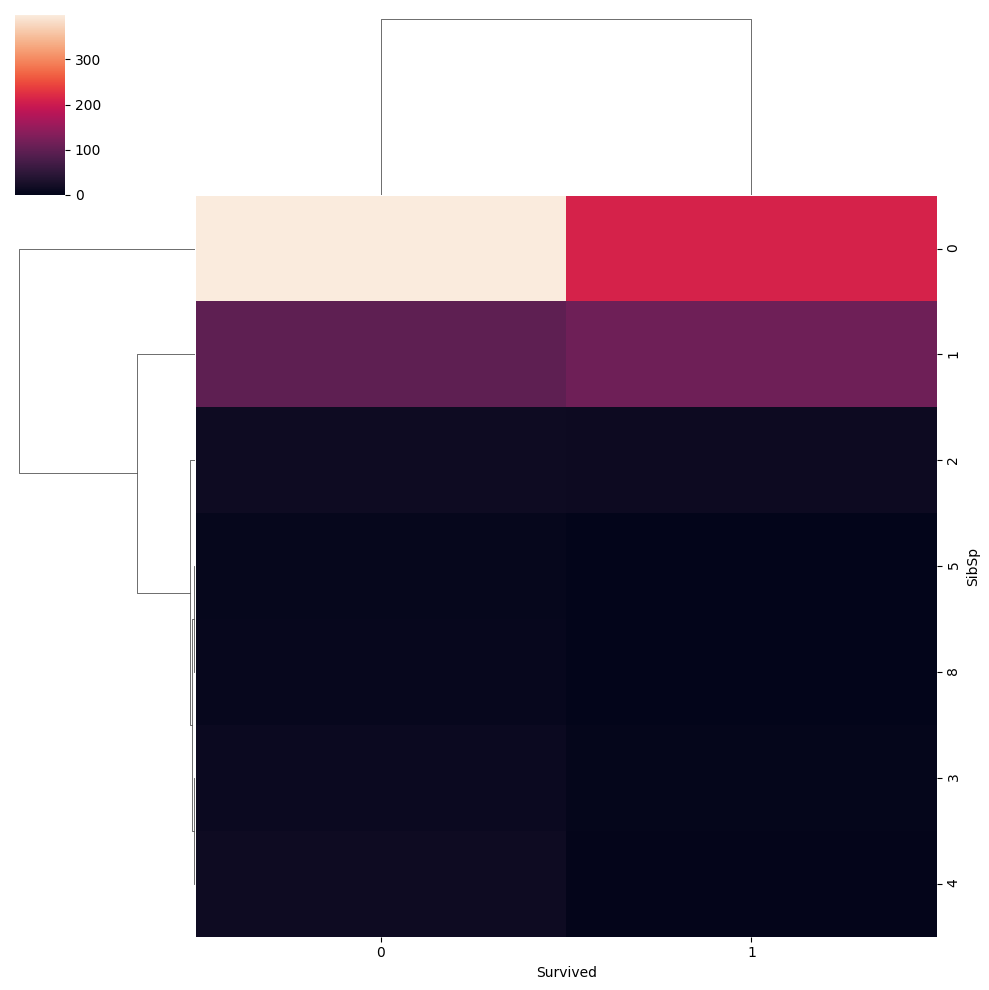

In [ ]:
sns.clustermap(pd.crosstab(titanic['SibSp'], titanic['Survived']))

# 7. Pairplot (All numerical values of the data)

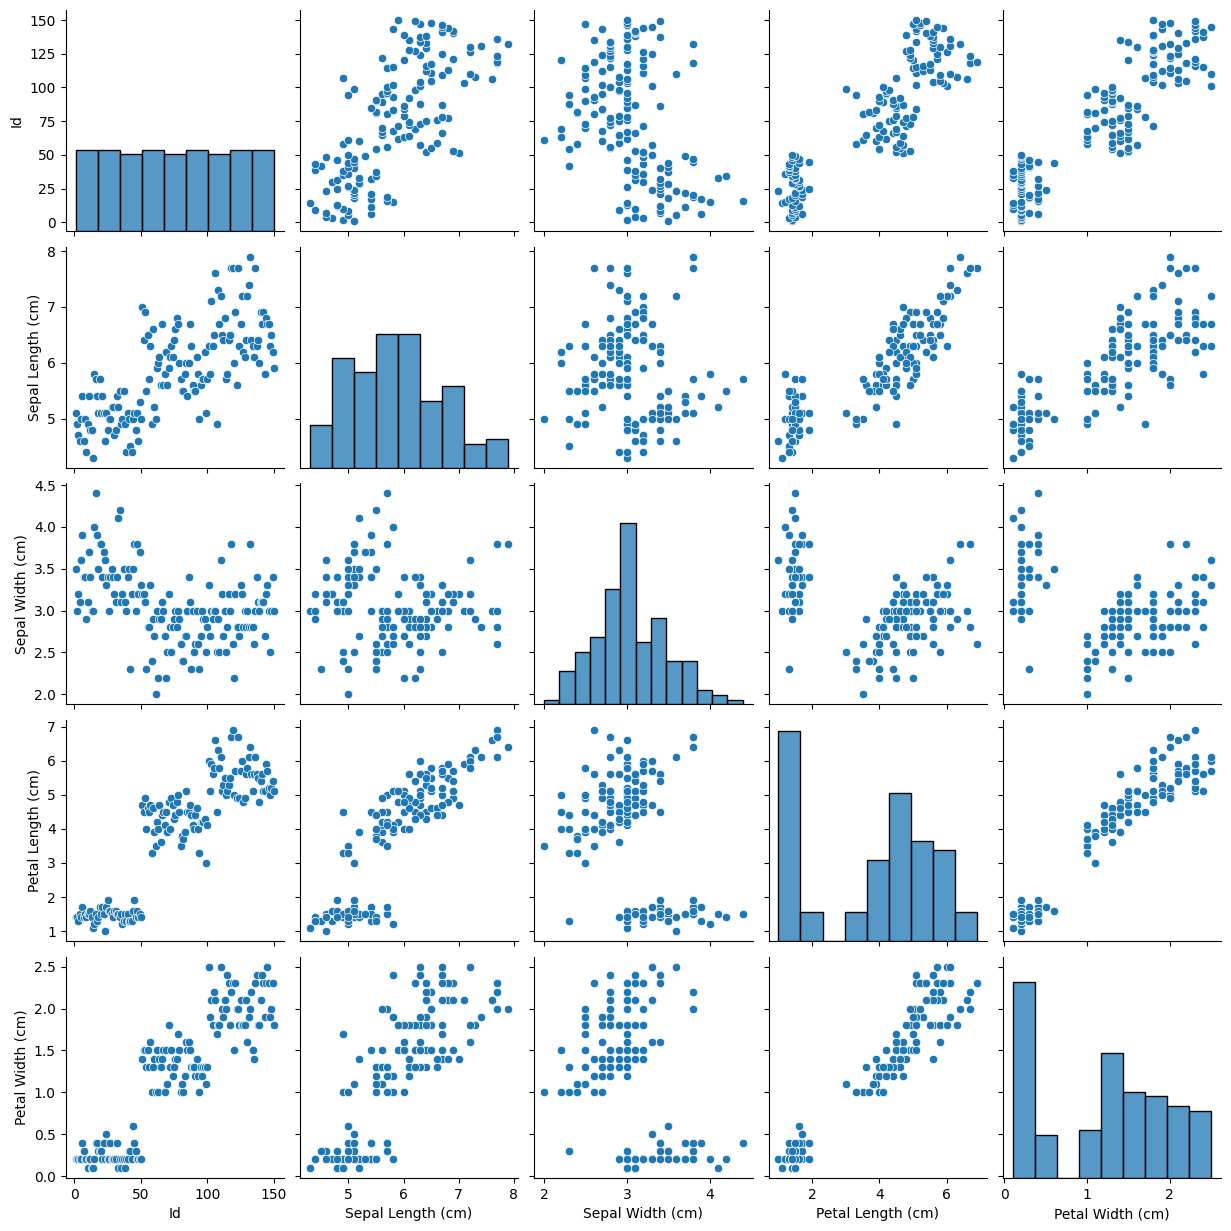

In [ ]:
sns.pairplot(iris)

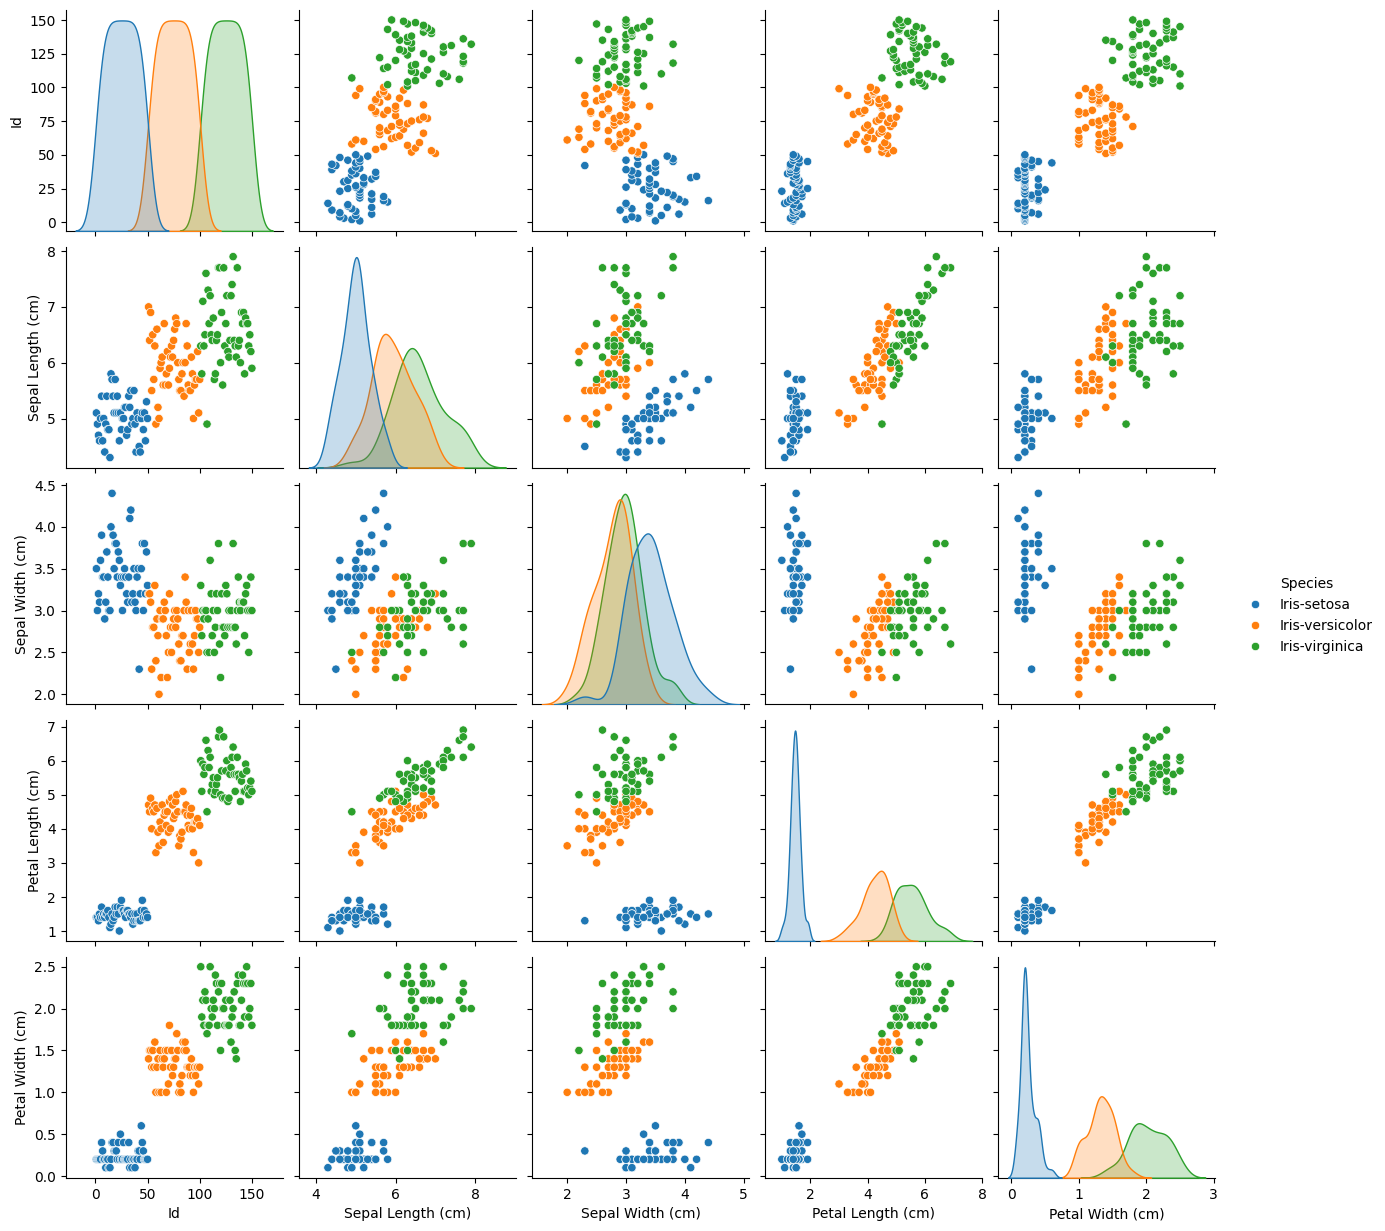

In [ ]:
sns.pairplot(iris, hue='Species')

# 8. Lineplot (Numerical - Numerical)
Used when x-axis is based on time(Year, month, day)

<Axes: xlabel='Fly Date', ylabel='Passengers'>

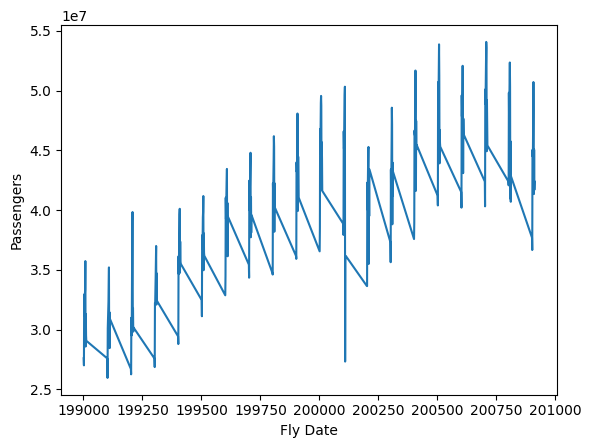

In [ ]:
new = flights.groupby('Fly Date').sum().reset_index()
sns.lineplot(x=new['Fly Date'], y=new['Passengers'])

<Axes: xlabel='Destination City', ylabel='Origin City'>

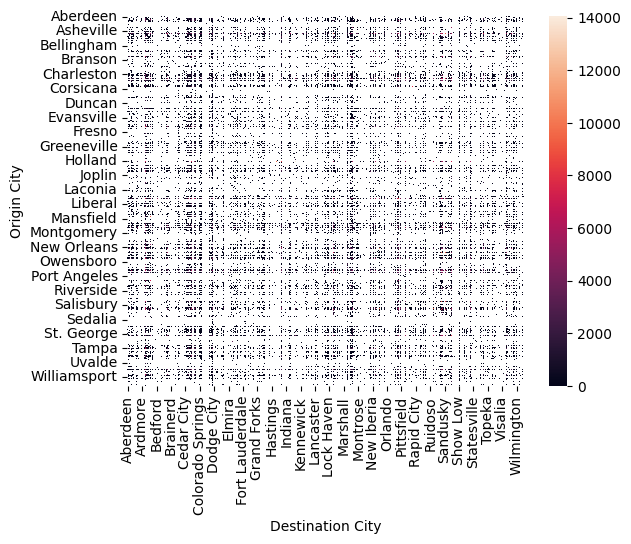

In [ ]:
sns.heatmap(flights.pivot_table(values='Passengers', index='Origin City', columns='Destination City'))

# **PANDAS PROFILING**

In [ ]:
!pip install ydata-profiling

In [ ]:
from ydata_profiling import ProfileReport

/tmp/ipykernel_30259/44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [ ]:
prof = ProfileReport(titanic)
prof.to_file(output_file='titanic.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:01<00:00, 10.43it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]